# Reading the file


In [262]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [263]:
df=pd.read_csv('FINALSET.csv')

In [264]:
df.head()

,Date,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,PS,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg,Cluster_Label
0,1990-01-01,25.438333,22.776667,25.558333,4.303333,27.983333,23.680,17.335000,85.625000,100.558333,3.731667,5.241667,2.311667,0.646667,0.578333,0.576667,246.1120,301.2839,1
1,1990-01-11,24.637000,21.199000,24.792000,5.206000,27.725000,22.518,15.753000,81.599000,100.673000,2.985000,4.245000,2.019000,0.714000,0.668000,0.659000,201.8966,237.2716,1
2,1990-01-21,24.559333,20.202667,24.854000,7.052667,28.532000,21.480,14.798667,77.519333,100.670000,2.586667,3.802667,1.584667,0.586000,0.571333,0.580667,192.2845,180.1767,1
3,1990-02-01,25.503333,20.528333,26.280000,7.721667,29.900000,22.180,15.055000,75.051667,100.713333,3.031667,4.255000,1.913333,0.503333,0.521667,0.528333,40.6034,143.8716,1
4,1990-02-11,27.009000,22.133000,27.867000,6.830000,30.994000,24.167,16.651000,75.986000,100.651000,3.634000,4.939000,2.305000,0.456000,0.490000,0.497000,15.9914,107.4868,0


Skipping boxplot for column 'Date' as it is not numeric.


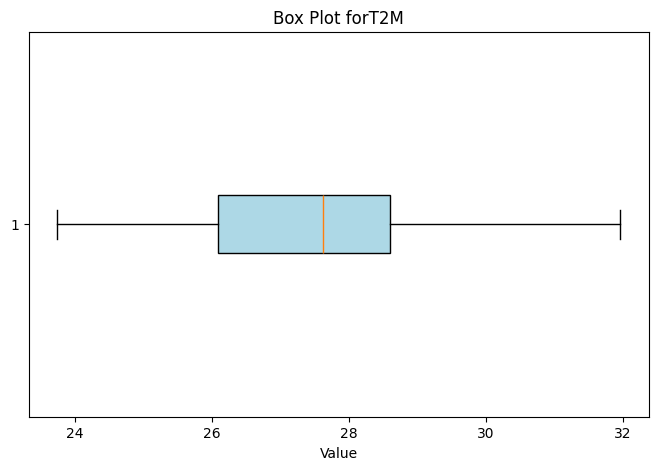

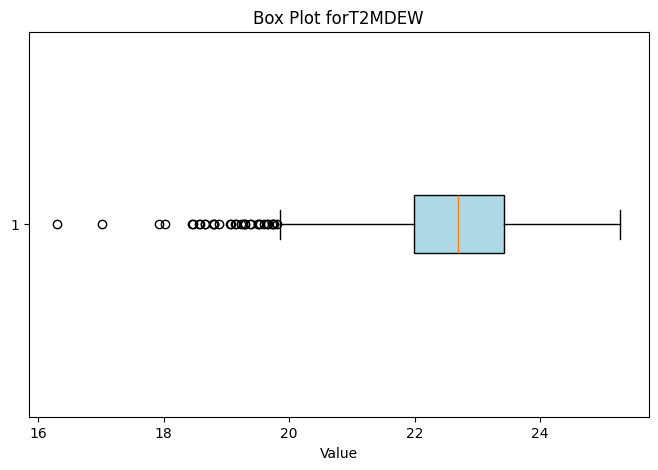

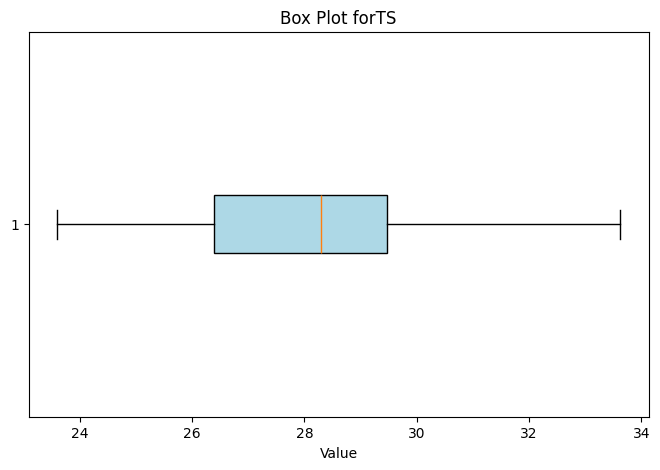

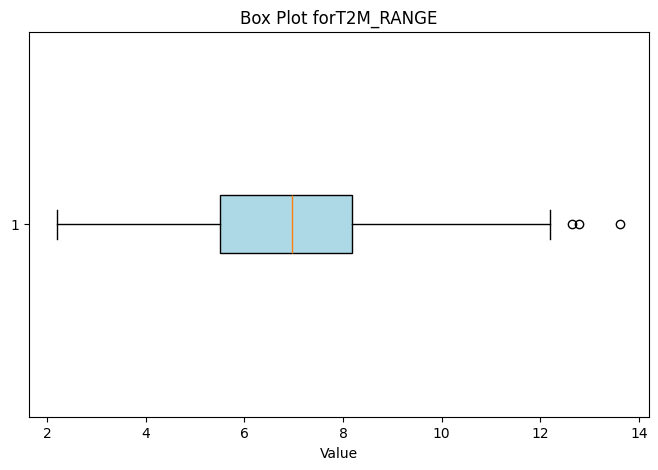

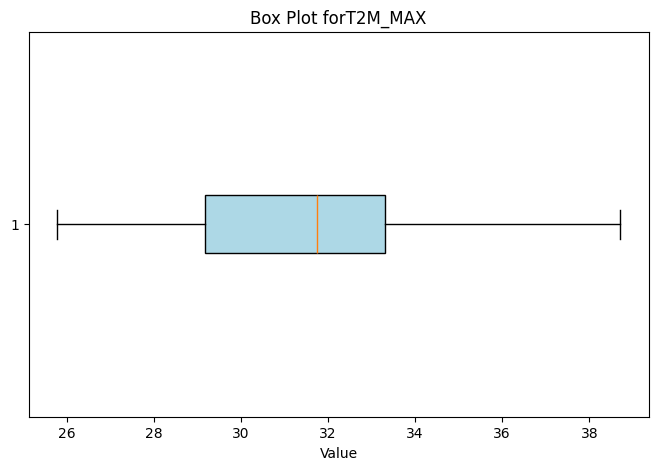

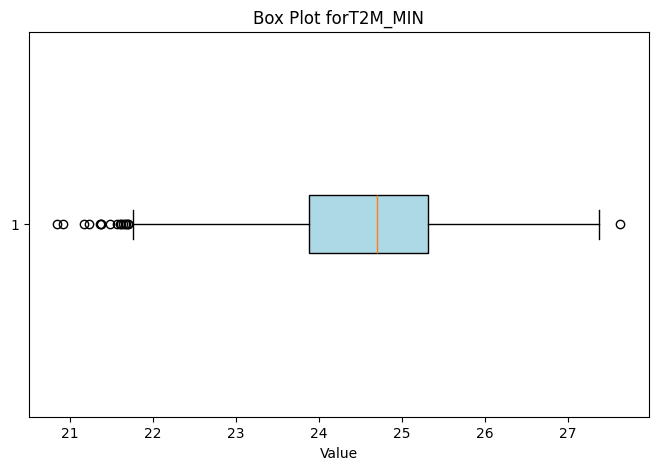

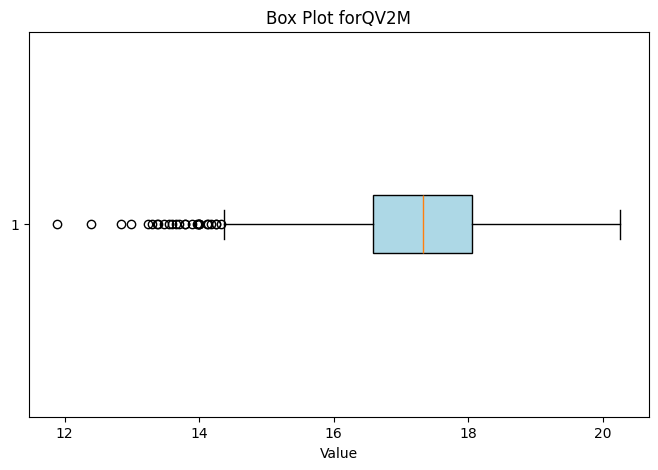

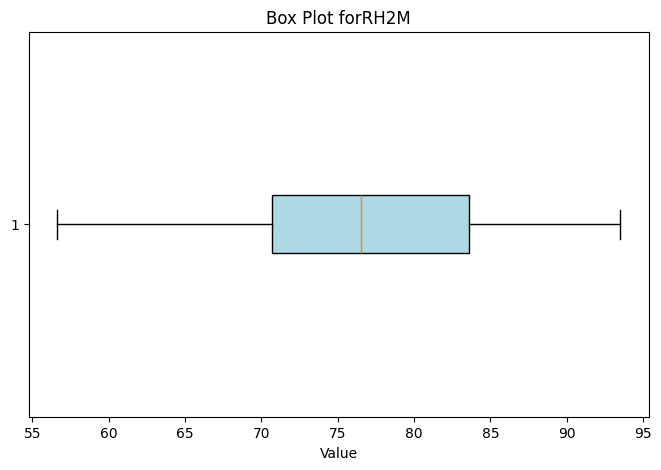

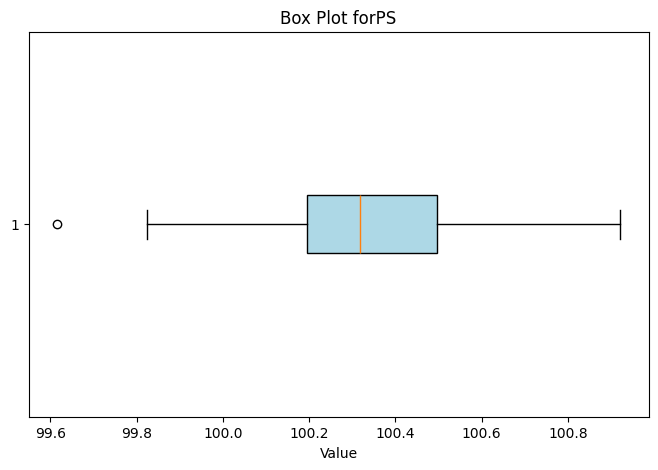

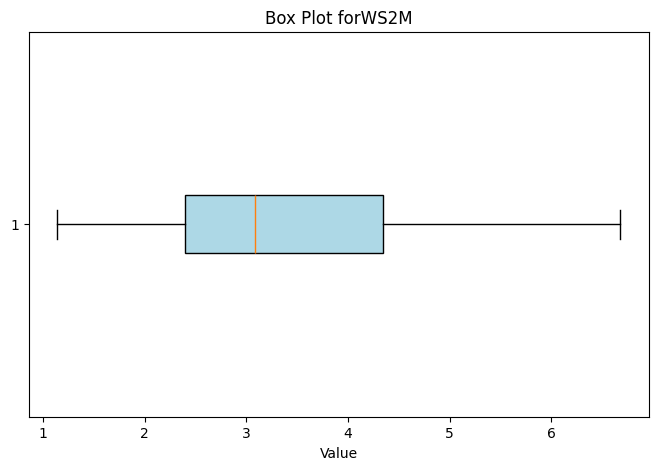

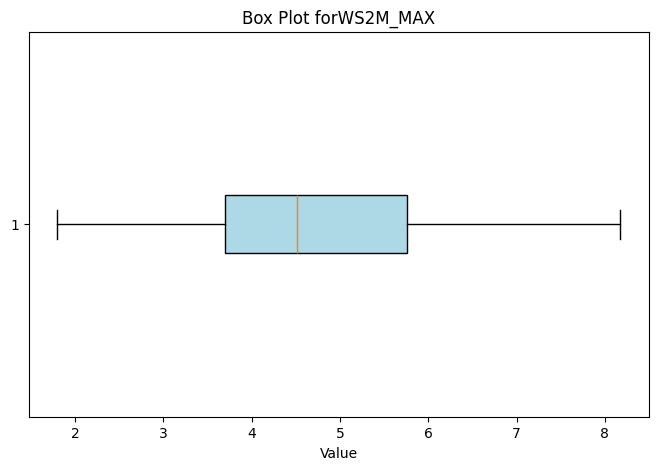

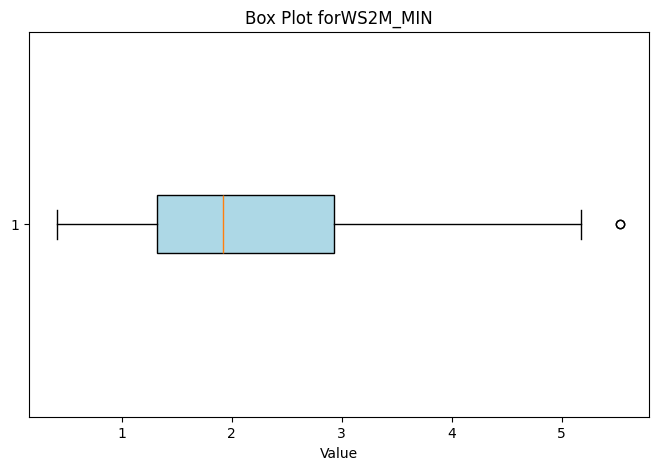

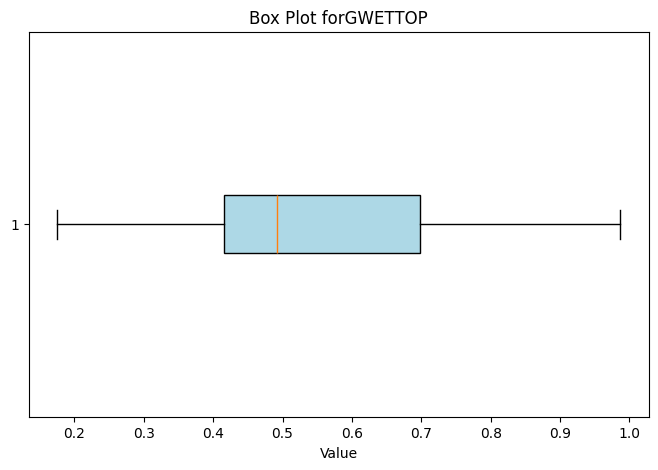

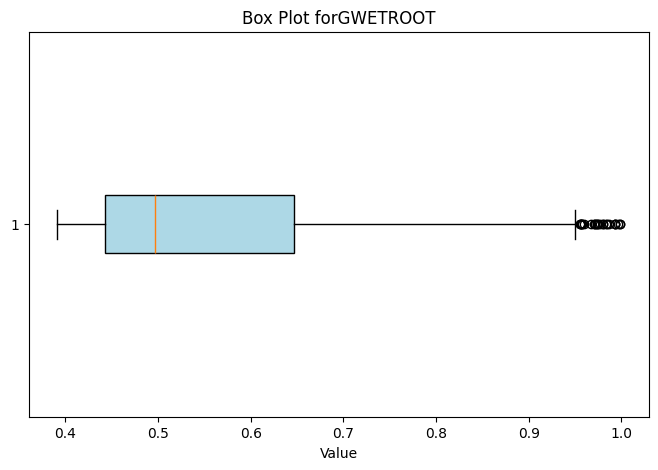

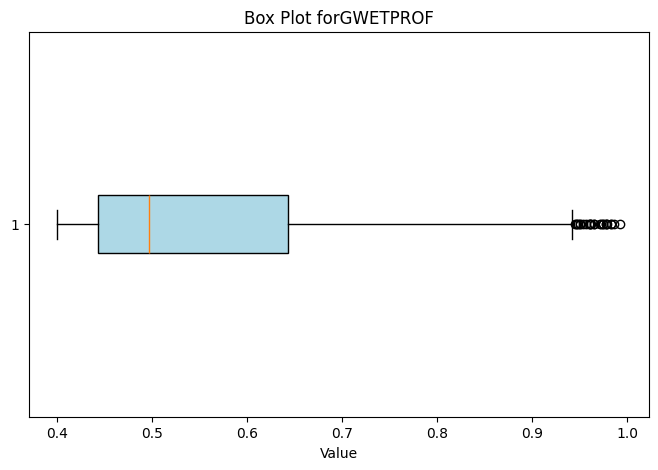

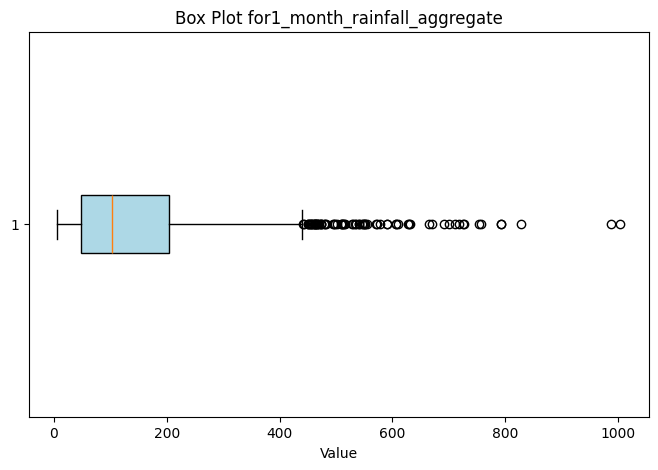

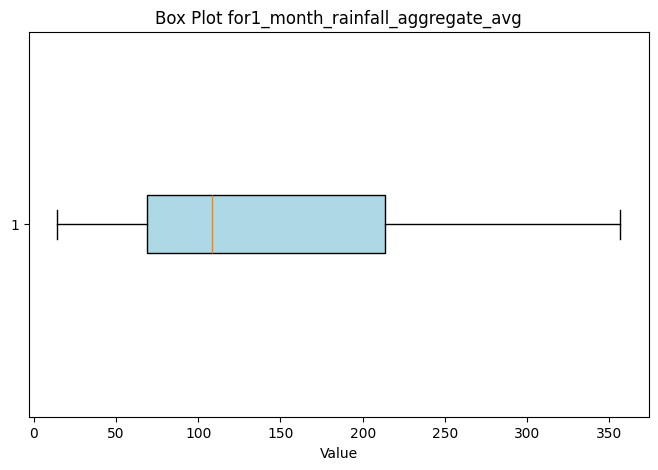

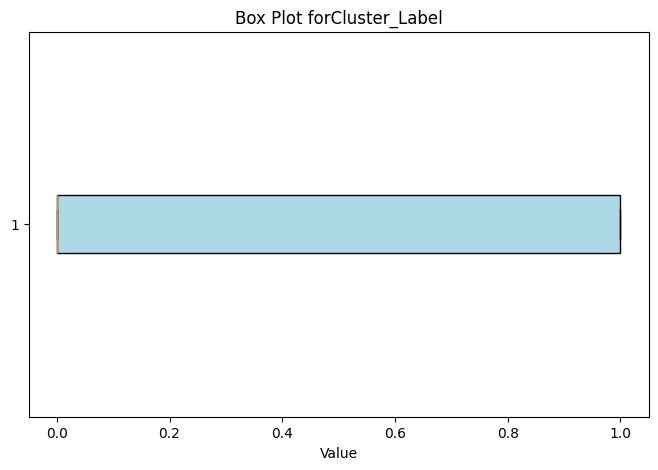

In [265]:
for col in df.columns:
    if df[col].dtype in [int, float]:
        plt.figure(figsize=(8, 5))
        plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
        plt.title("Box Plot for"+col)
        plt.xlabel("Value")
        plt.show()
    else:
        print(f"Skipping boxplot for column '{col}' as it is not numeric.")

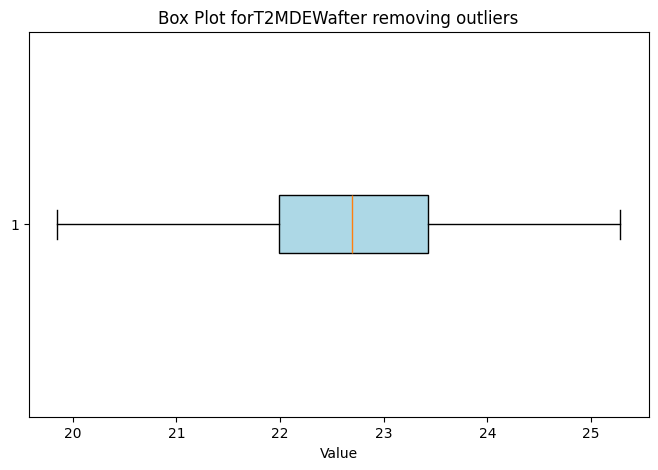

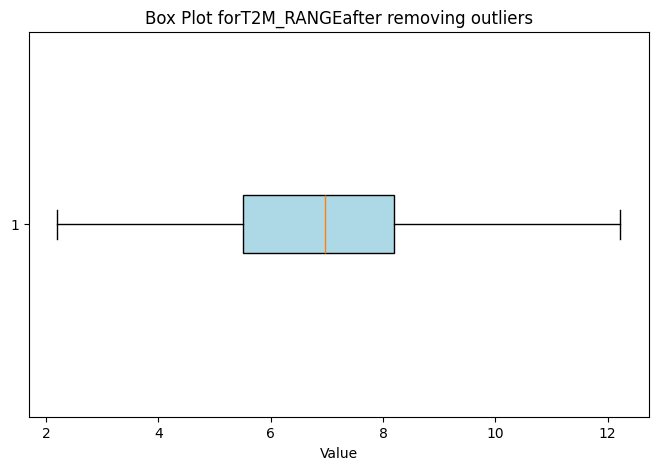

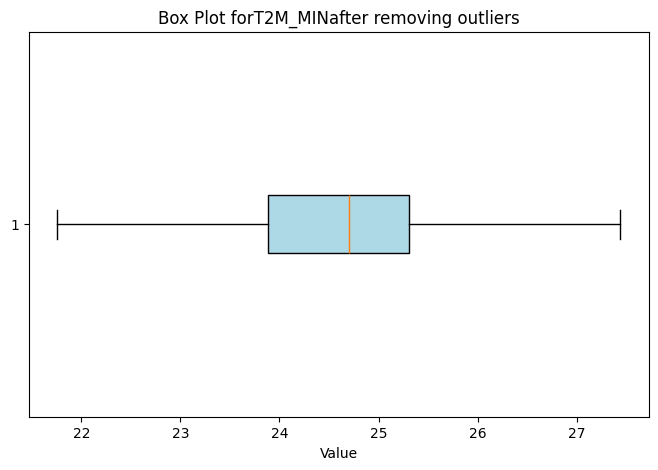

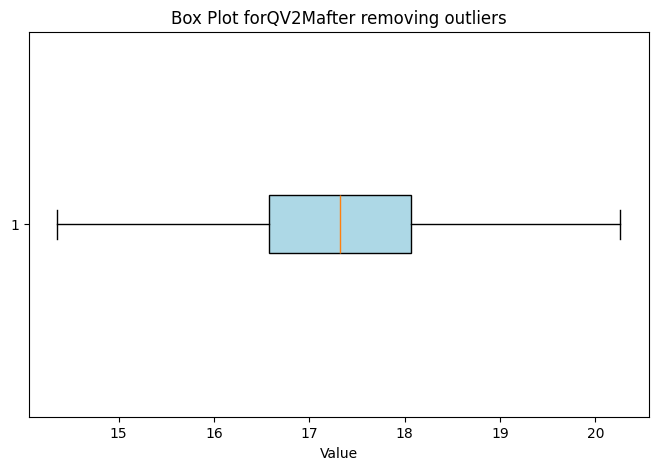

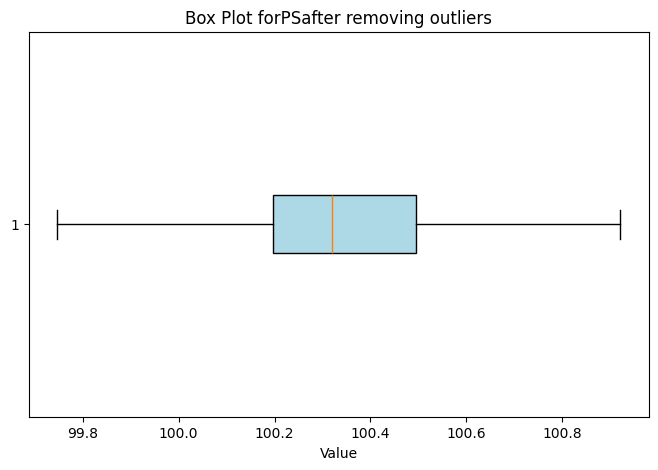

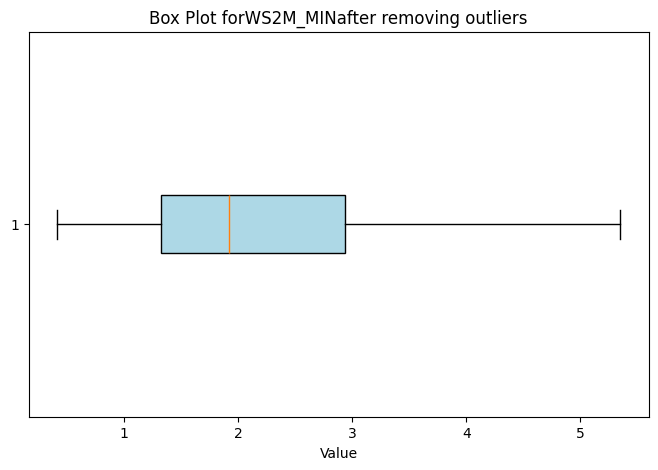

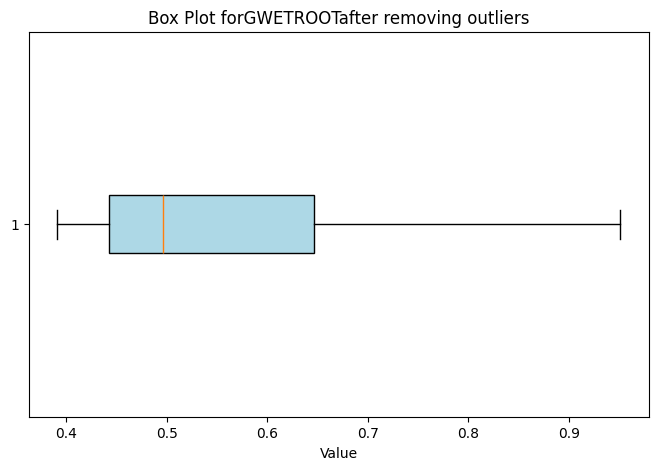

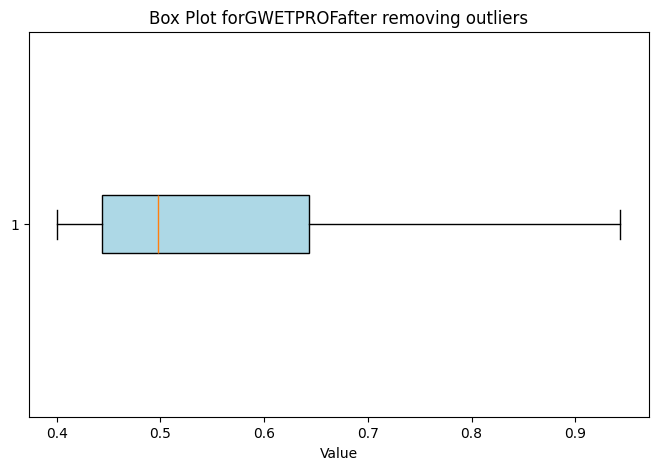

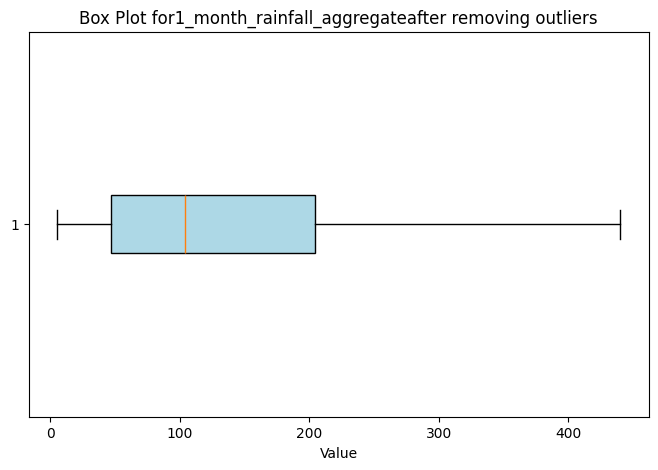

In [266]:
def capping(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
features_toCap=['T2MDEW','T2M_RANGE','T2M_MIN','QV2M','PS','WS2M_MIN','GWETROOT','GWETPROF','1_month_rainfall_aggregate']
for cols in features_toCap:
    capping(cols)
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[cols], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    plt.title("Box Plot for"+cols+"after removing outliers")
    plt.xlabel("Value")
    plt.show()


In [267]:
df.head()

,Date,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,PS,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg,Cluster_Label
0,1990-01-01,25.438333,22.776667,25.558333,4.303333,27.983333,23.680000,17.335000,85.625000,100.558333,3.731667,5.241667,2.311667,0.646667,0.578333,0.576667,246.1120,301.2839,1
1,1990-01-11,24.637000,21.199000,24.792000,5.206000,27.725000,22.518000,15.753000,81.599000,100.673000,2.985000,4.245000,2.019000,0.714000,0.668000,0.659000,201.8966,237.2716,1
2,1990-01-21,24.559333,20.202667,24.854000,7.052667,28.532000,21.751167,14.798667,77.519333,100.670000,2.586667,3.802667,1.584667,0.586000,0.571333,0.580667,192.2845,180.1767,1
3,1990-02-01,25.503333,20.528333,26.280000,7.721667,29.900000,22.180000,15.055000,75.051667,100.713333,3.031667,4.255000,1.913333,0.503333,0.521667,0.528333,40.6034,143.8716,1
4,1990-02-11,27.009000,22.133000,27.867000,6.830000,30.994000,24.167000,16.651000,75.986000,100.651000,3.634000,4.939000,2.305000,0.456000,0.490000,0.497000,15.9914,107.4868,0


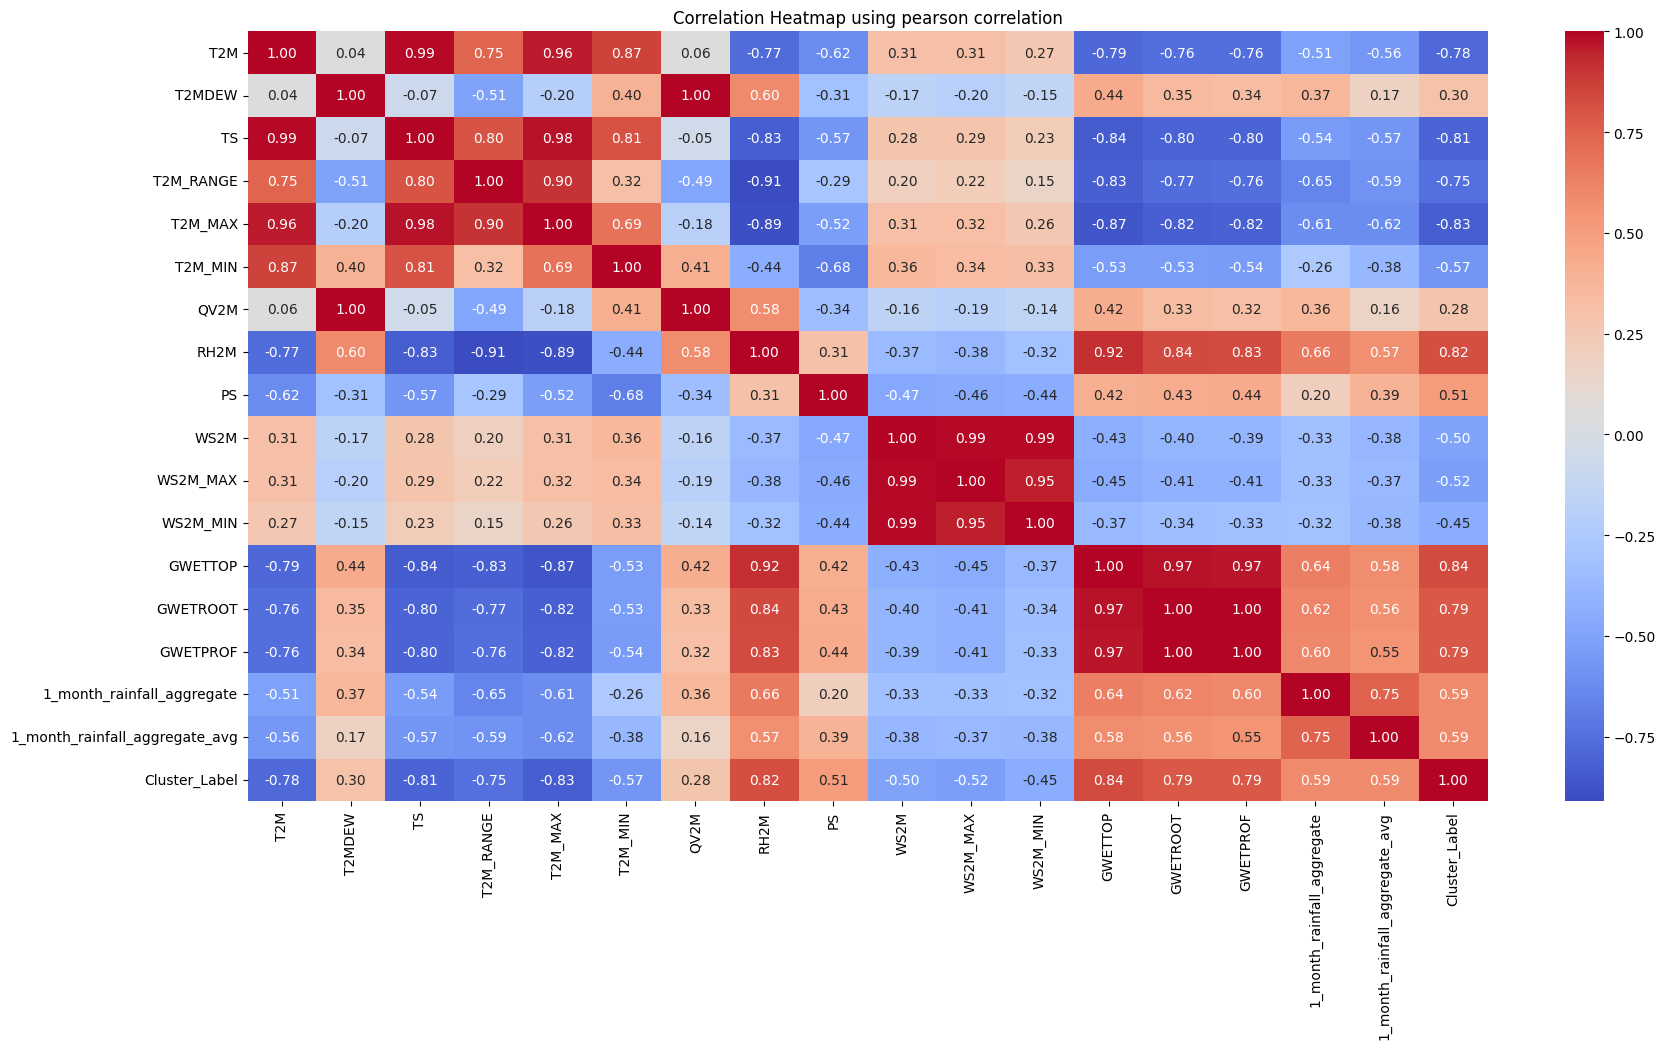

TS and T2M: 0.9884586399612422
T2M_MAX and T2M: 0.9570542239464621
QV2M and T2MDEW: 0.998783600157263
T2M and TS: 0.9884586399612422
T2M_MAX and TS: 0.9751975330724337
T2M_MAX and T2M_RANGE: 0.9039949192160772
T2M and T2M_MAX: 0.9570542239464621
TS and T2M_MAX: 0.9751975330724337
T2M_RANGE and T2M_MAX: 0.9039949192160772
T2MDEW and QV2M: 0.998783600157263
GWETTOP and RH2M: 0.9172303179564621
WS2M_MAX and WS2M: 0.9875027798499162
WS2M_MIN and WS2M: 0.9851085856257827
WS2M and WS2M_MAX: 0.9875027798499162
WS2M_MIN and WS2M_MAX: 0.9528258793404496
WS2M and WS2M_MIN: 0.9851085856257827
WS2M_MAX and WS2M_MIN: 0.9528258793404496
RH2M and GWETTOP: 0.9172303179564621
GWETROOT and GWETTOP: 0.972074368828962
GWETPROF and GWETTOP: 0.9672273659922899
GWETTOP and GWETROOT: 0.972074368828962
GWETPROF and GWETROOT: 0.9990497153040525
GWETTOP and GWETPROF: 0.9672273659922899
GWETROOT and GWETPROF: 0.9990497153040525
{'QV2M', 'T2M_RANGE', 'GWETTOP', 'WS2M', 'T2M', 'GWETROOT', 'WS2M_MIN', 'TS', 'T2MDEW'

In [268]:
correlation_matrix = df.drop(columns="Date").corr(method="pearson")

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap using pearson correlation")
plt.show()

higly_correlated_features=set()
names_of_features=[]

for col in correlation_matrix.columns:
    for index in correlation_matrix.index:
        if correlation_matrix.loc[index, col] > 0.9 and index != col:
            print(f"{index} and {col}: {correlation_matrix.loc[index, col]}")
            higly_correlated_features.add(index)
print(higly_correlated_features)
for features in higly_correlated_features:
    names_of_features.append(features)

print(names_of_features)



In [269]:
df=df.drop(['TS','T2M_MAX','QV2M','WS2M_MIN','WS2M_MAX','GWETPROF','GWETROOT','Date'],axis=1)

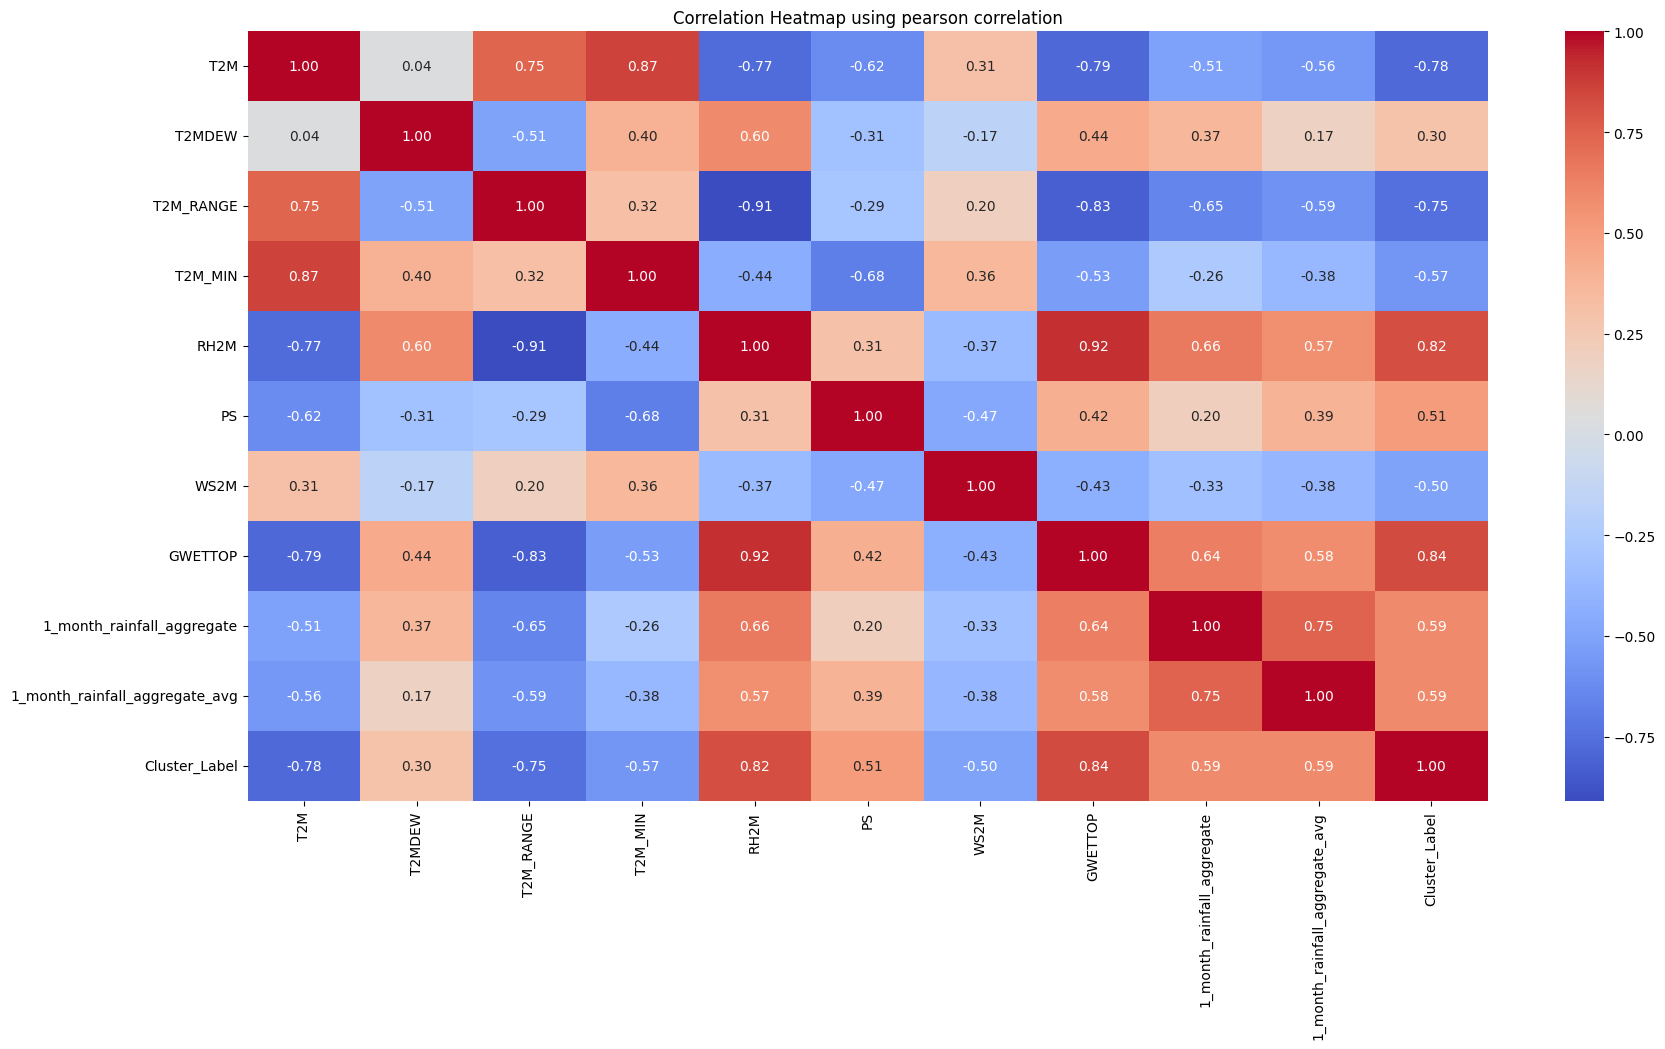

In [270]:
correlation_matrix = df.corr(method="pearson")

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap using pearson correlation")
plt.show()

# Selecting Features with more Importance


                          Feature  Importance
7                         GWETTOP    0.344399
4                            RH2M    0.226969
0                             T2M    0.149437
2                       T2M_RANGE    0.127646
6                            WS2M    0.036383
3                         T2M_MIN    0.031095
8      1_month_rainfall_aggregate    0.025915
9  1_month_rainfall_aggregate_avg    0.020400
1                          T2MDEW    0.019368
5                              PS    0.018388


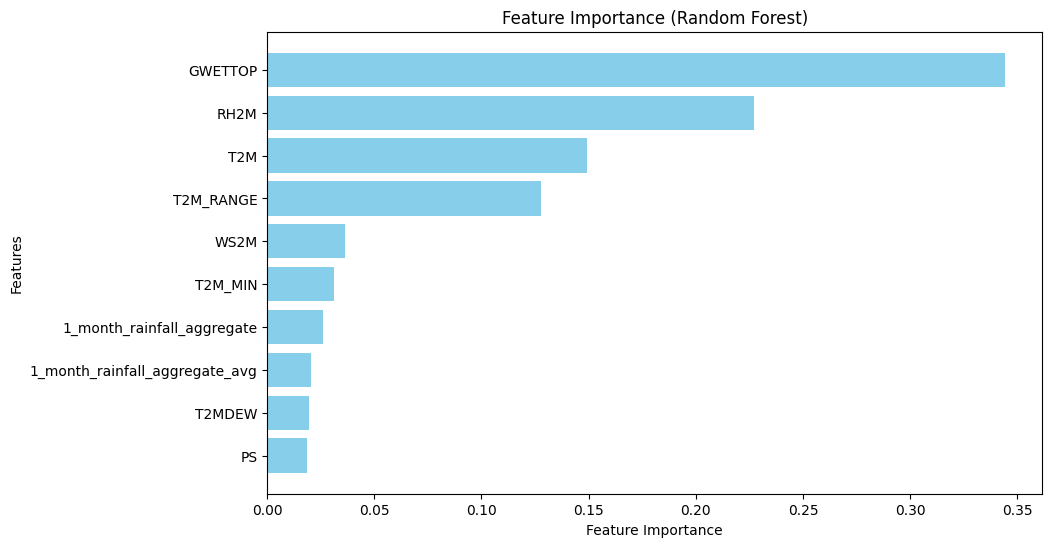

In [271]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

x_train=df.drop(columns=['Cluster_Label'])
y_train=df['Cluster_Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)


feature_importances = rf.feature_importances_

features = x_train.columns  
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})



importance_df = importance_df.sort_values(by='Importance', ascending=False)


print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


# Used Min Max Scaler to normalize the dataset

In [272]:
from sklearn.preprocessing import StandardScaler

X=df.drop('Cluster_Label',axis=1)

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()


,T2M,T2MDEW,T2M_RANGE,T2M_MIN,RH2M,PS,WS2M,GWETTOP,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg
0,-1.277358,0.117265,-1.383790,-0.771756,1.135865,1.062762,0.275779,0.542106,0.818038,1.457695
1,-1.791943,-1.311215,-0.901592,-1.826561,0.611183,1.638734,-0.329473,0.924377,0.463706,0.842608
2,-1.841817,-2.213334,0.084884,-2.522654,0.079508,1.623665,-0.652364,0.197685,0.386677,0.293990
3,-1.235617,-1.918462,0.442259,-2.133380,-0.242087,1.841329,-0.291644,-0.271637,-0.828862,-0.054861
4,-0.268737,-0.465535,-0.034063,-0.329682,-0.120322,1.528228,0.196610,-0.540362,-1.026098,-0.404478


# Apply PCA

In [273]:
from sklearn.decomposition import PCA
pca=PCA(0.95)
X_pca=pca.fit_transform(df[['WS2M','T2M_MIN','1_month_rainfall_aggregate','1_month_rainfall_aggregate_avg','T2MDEW','PS']])

explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.88108472, 0.11878717])

In [274]:
import numpy as np
pca_columns = X_pca[:, :2]
scaled_pca=scaler.fit_transform(pca_columns)
pca_data = np.concatenate([scaled_pca], axis=1)
pca_df = pd.DataFrame(pca_data, columns=['PCACOMP1','PCACOMP2'])
pca_df.head()




,PCACOMP1,PCACOMP2
0,1.140896,1.002092
1,0.653613,0.592133
2,0.372667,-0.102832
3,-0.556082,1.062007
4,-0.830400,0.822788


In [275]:
df1 = pd.concat([Scaled_df, pca_df], axis=1)
df1.head()

,T2M,T2MDEW,T2M_RANGE,T2M_MIN,RH2M,PS,WS2M,GWETTOP,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg,PCACOMP1,PCACOMP2
0,-1.277358,0.117265,-1.383790,-0.771756,1.135865,1.062762,0.275779,0.542106,0.818038,1.457695,1.140896,1.002092
1,-1.791943,-1.311215,-0.901592,-1.826561,0.611183,1.638734,-0.329473,0.924377,0.463706,0.842608,0.653613,0.592133
2,-1.841817,-2.213334,0.084884,-2.522654,0.079508,1.623665,-0.652364,0.197685,0.386677,0.293990,0.372667,-0.102832
3,-1.235617,-1.918462,0.442259,-2.133380,-0.242087,1.841329,-0.291644,-0.271637,-0.828862,-0.054861,-0.556082,1.062007
4,-0.268737,-0.465535,-0.034063,-0.329682,-0.120322,1.528228,0.196610,-0.540362,-1.026098,-0.404478,-0.830400,0.822788


In [276]:
df2=df1.drop(['WS2M','T2M_MIN','1_month_rainfall_aggregate','1_month_rainfall_aggregate_avg','T2MDEW','PS'],axis=1)

# Merging label data

In [277]:
main_df=pd.concat([df['Cluster_Label'],df2], axis=1)
main_df.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2
0,1,-1.277358,-1.383790,1.135865,0.542106,1.140896,1.002092
1,1,-1.791943,-0.901592,0.611183,0.924377,0.653613,0.592133
2,1,-1.841817,0.084884,0.079508,0.197685,0.372667,-0.102832
3,1,-1.235617,0.442259,-0.242087,-0.271637,-0.556082,1.062007
4,0,-0.268737,-0.034063,-0.120322,-0.540362,-0.830400,0.822788


In [279]:
main_df.to_csv('DSGP1.csv', index=False)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



X=df.drop(columns=['Cluster_Label'])
Y=df['Cluster_Label']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

from sklearn.metrics import classification_report
y_pred=rf.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       205
           1       0.99      0.94      0.97       152

    accuracy                           0.97       357
   macro avg       0.98      0.97      0.97       357
weighted avg       0.97      0.97      0.97       357



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # Corrected the import statement
from sklearn.metrics import log_loss, classification_report
import numpy as np

# Prepare the dataset (replace df with your actual dataframe)
X = df.drop(columns=['Cluster_Label'])
Y = df['Cluster_Label']

# Perform the train-test split only once
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model once
log_reg = LogisticRegression(random_state=42, max_iter=1000)
# Simulate multiple training epochs (iterations)
training_losses = []
validation_losses = []

for epoch in range(10):  # Simulating 10 epochs
    # Train the Logistic Regression model
    log_reg.fit(X_train, Y_train)

    # Predict probabilities for log loss calculation
    y_train_prob = log_reg.predict_proba(X_train)  # Probabilities using log_reg
    y_test_prob = log_reg.predict_proba(X_test)    # Probabilities using log_reg

    # Calculate log loss (training and validation)
    train_loss = log_loss(Y_train, y_train_prob)
    val_loss = log_loss(Y_test, y_test_prob)

    training_losses.append(train_loss)
    validation_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

# Generate classification report for validation data
y_pred = log_reg.predict(X_test)  # Predictions using log_reg
print(classification_report(Y_test, y_pred))


Epoch 1: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 2: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 3: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 4: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 5: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 6: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 7: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 8: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 9: Training Loss = 0.0309, Validation Loss = 0.0434
Epoch 10: Training Loss = 0.0309, Validation Loss = 0.0434
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       205
           1       0.99      0.97      0.98       152

    accuracy                           0.98       357
   macro avg       0.98      0.98      0.98       357
weighted avg       0.98      0.98      0.98       357



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.94779557 0.96584386 0.98295739 0.96132016 0.95740474]
Mean F1-Score: 0.9630643442125593


In [260]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Convert the DataFrame to PyTorch tensors
# Assuming 'Cluster_Label' is your target variable
inputs = torch.tensor(main_df.drop(columns=['Cluster_Label']).values, dtype=torch.float32)
targets = torch.tensor(main_df['Cluster_Label'].values, dtype=torch.long)  # Use torch.long for classification targets

# Create a TensorDataset
dataset = TensorDataset(inputs, targets)

# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(dataset, [int(0.7 * len(dataset)), len(dataset) - int(0.7 * len(dataset))])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ... (rest of your model and training code)

Epoch 1/10, Training Loss: 0.7050, Validation Loss: 0.5877
Epoch 2/10, Training Loss: 0.4954, Validation Loss: 0.4040
Epoch 3/10, Training Loss: 0.3308, Validation Loss: 0.2684
Epoch 4/10, Training Loss: 0.2229, Validation Loss: 0.1904
Epoch 5/10, Training Loss: 0.1633, Validation Loss: 0.1474
Epoch 6/10, Training Loss: 0.1302, Validation Loss: 0.1213
Epoch 7/10, Training Loss: 0.1088, Validation Loss: 0.1022
Epoch 8/10, Training Loss: 0.0942, Validation Loss: 0.0884
Epoch 9/10, Training Loss: 0.0833, Validation Loss: 0.0781
Epoch 10/10, Training Loss: 0.0751, Validation Loss: 0.0700


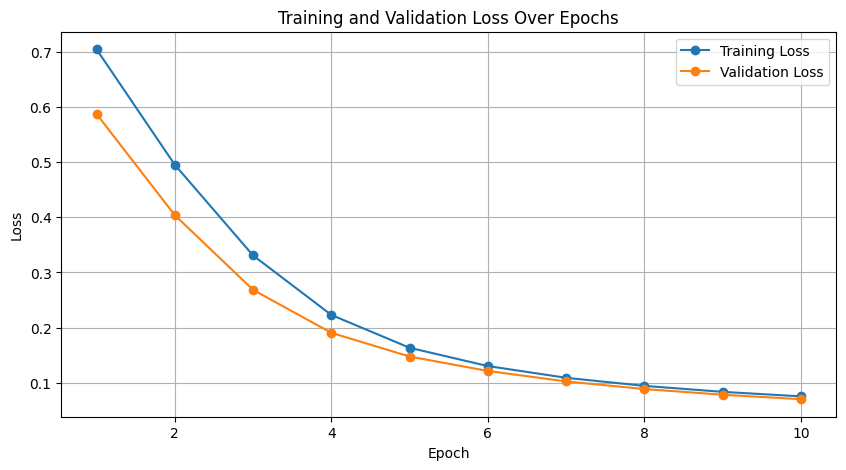

ValueError: Found input variables with inconsistent numbers of samples: [357, 5]

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split,TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

inputs = torch.tensor(main_df.drop(columns=['Cluster_Label']).values, dtype=torch.float32)
targets = torch.tensor(main_df['Cluster_Label'].values, dtype=torch.long)

dataset = TensorDataset(inputs, targets)

train_dataset, val_dataset = random_split(dataset, [int(0.7 * len(main_df)), len(main_df) - int(0.7 * len(main_df))])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Get the number of input features from your data
input_size = inputs.shape[1]  # inputs.shape[1] will give you the number of features (columns) in your input data

# Update the model definition with the correct input size
model = nn.Sequential(
    nn.Linear(input_size, 32),  # Change input size to match your data
    nn.ReLU(),
    nn.Linear(32, 2)
)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10
training_losses = []
validation_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    training_losses.append(train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    validation_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), training_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), validation_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import classification_report

y_pred = torch.argmax(model(inputs), dim=1)
print(classification_report(Y_test, y_pred))